# SWAPNET comparison (self-contained notebook)

This notebook contains **all** circuit construction, simulation, parsing, and plotting logic for **$N=3$**, **$k=2$**:

1. **Dynamic** — measure swap-test ancilla + `if_test` + cyclic SWAP routing.
2. **Coherent Fredkin** — Schur layer + Fredkin-style CSWAP routing (no `if_test`).

**Fidelity** = fraction of shots with reserve register $R_3$ read out as $|00\rangle$.

There is **no** import from `swapnet_n3_compare.py`; that CLI script mirrors this code for batch use.

## Prerequisites

```bash
pip install numpy matplotlib qiskit qiskit-aer ipykernel pylatexenc pillow
```

In [ ]:
from __future__ import annotations

from collections import Counter
from itertools import product
from pathlib import Path
from typing import Any, Callable, Dict, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import depolarizing_error
from qiskit_aer.primitives import SamplerV2 as AerSampler


## Constants and initial depolarizing noise

Each of the three $k$-qubit data registers gets an independent global depolarizing channel with probability $\lambda \in [0,1]$ before either protocol.

In [ ]:
N_REGS = 3
K = 2


def append_initial_depolarizing(
    qc: QuantumCircuit,
    qr_data: Sequence[QuantumRegister],
    lambda_: float,
    k: int,
) -> None:
    if lambda_ <= 0.0:
        return
    chan = depolarizing_error(lambda_, k)
    for reg in qr_data:
        qc.append(chan, reg[:])


## A. Dynamic circuit (`if_test`)

Matches the OQPA `DynamicStrategy`: Schur swap-test, measure ancilla, classical branching, unconditional SWAP cyclic permutation per branch, recurse.

In [ ]:
def append_schur_test(
    qc: QuantumCircuit, ancilla, reg_a: QuantumRegister, reg_b: QuantumRegister, k: int
) -> None:
    qc.h(ancilla)
    for i in range(k):
        qc.cswap(ancilla, reg_a[i], reg_b[i])
    qc.h(ancilla)


def append_cyclic_rotation(qc: QuantumCircuit, regs: Sequence[QuantumRegister], kbits: int) -> None:
    n = len(regs)
    for i in range(kbits):
        for j in range(n - 1, 0, -1):
            qc.swap(regs[j][i], regs[j - 1][i])


def make_dynamic_registers(
    n_registers: int, k: int, n_trials: int
) -> Tuple[
    List[QuantumRegister],
    QuantumRegister,
    QuantumRegister,
    List[ClassicalRegister],
    ClassicalRegister,
    ClassicalRegister,
]:
    qr_data = [QuantumRegister(k, f"R{i + 1}") for i in range(n_registers)]

    max_parallel = (n_registers - 1) // 2
    qr_ctrl_par = QuantumRegister(max_parallel, "ctrl_par")
    qr_ctrl_rec = QuantumRegister(1, "ctrl_rec")

    cr_pool = [ClassicalRegister(max_parallel, f"res_t{t}") for t in range(n_trials)]
    cr_rec = ClassicalRegister(n_trials, "res_rec")
    cr_readout = ClassicalRegister(k, "readout")

    return qr_data, qr_ctrl_par, qr_ctrl_rec, cr_pool, cr_rec, cr_readout


def append_recursive_qpa_layer(
    qc: QuantumCircuit,
    current_pairs: List[Tuple[QuantumRegister, QuantumRegister]],
    reserve_reg: QuantumRegister,
    qr_ctrl_par: QuantumRegister,
    cr_pool: Sequence[ClassicalRegister],
    k: int,
    n_trials: int,
    current_trial: int,
) -> None:
    if current_trial >= n_trials:
        return

    num_pairs = len(current_pairs)
    current_cr = cr_pool[current_trial]

    for i in range(num_pairs):
        append_schur_test(qc, qr_ctrl_par[i], current_pairs[i][0], current_pairs[i][1], k)
        qc.measure(qr_ctrl_par[i], current_cr[i])
        qc.reset(qr_ctrl_par[i])

    outcomes = list(product([0, 1], repeat=num_pairs))

    for outcome in outcomes:
        conditions = [(current_cr[i], val) for i, val in enumerate(outcome)]

        def apply_conditions(cond_list: List[Tuple], block_func: Callable[[], None]) -> None:
            if not cond_list:
                block_func()
                return
            head, *tail = cond_list
            with qc.if_test(head):  # type: ignore[misc]
                apply_conditions(tail, block_func)

        def logic_block() -> None:
            if all(v == 0 for v in outcome):
                all_regs: List[QuantumRegister] = []
                for pair in current_pairs:
                    all_regs.extend([pair[0], pair[1]])
                all_regs.append(reserve_reg)
                append_cyclic_rotation(qc, all_regs, k)
                append_recursive_qpa_layer(
                    qc,
                    current_pairs,
                    reserve_reg,
                    qr_ctrl_par,
                    cr_pool,
                    k,
                    n_trials,
                    current_trial + 1,
                )
                return

            surviving_pairs = [
                current_pairs[i] for i, val in enumerate(outcome) if val == 0
            ]
            if not surviving_pairs:
                return

            active_regs: List[QuantumRegister] = []
            for pair in surviving_pairs:
                active_regs.extend([pair[0], pair[1]])
            active_regs.append(reserve_reg)

            append_cyclic_rotation(qc, active_regs, k)

            new_pairs = [
                (active_regs[j], active_regs[j + 1])
                for j in range(0, len(active_regs) - 1, 2)
            ]
            new_reserve = active_regs[-1]

            append_recursive_qpa_layer(
                qc,
                new_pairs,
                new_reserve,
                qr_ctrl_par,
                cr_pool,
                k,
                n_trials,
                current_trial + 1,
            )

        apply_conditions(conditions, logic_block)


def build_dynamic_circuit(lambda_: float, n_trials: int) -> QuantumCircuit:
    qr_data, qr_ctrl_par, qr_ctrl_rec, cr_pool, cr_rec, cr_readout = make_dynamic_registers(
        N_REGS, K, n_trials
    )

    qc = QuantumCircuit(
        *qr_data,
        qr_ctrl_par,
        qr_ctrl_rec,
        *cr_pool,
        cr_rec,
        cr_readout,
    )

    append_initial_depolarizing(qc, qr_data, lambda_, K)

    reserve = qr_data[N_REGS - 1]
    initial_pairs: List[Tuple[QuantumRegister, QuantumRegister]] = [
        (qr_data[i], qr_data[i + 1]) for i in range(0, N_REGS - 1, 2)
    ]

    append_recursive_qpa_layer(
        qc,
        initial_pairs,
        reserve,
        qr_ctrl_par,
        cr_pool,
        K,
        n_trials,
        current_trial=0,
    )
    qc.measure(reserve, cr_readout)

    return qc


## B. Coherent Fredkin circuit

Same Schur layer, then cyclic routing implemented with `X`–Fredkin–`X` on the trial ancilla. Deeper trials use multiply-controlled trial unitaries (`ctrl_state='0'*t`) so later layers fire only if earlier swap-tests would have succeeded ($|0\rangle$ on each prior ancilla).

In [ ]:
def single_trial_unitary_gate(k: int):
    n = 1 + 3 * k
    qc = QuantumCircuit(n)
    anc = 0
    r1 = list(range(1, k + 1))
    r2 = list(range(k + 1, 2 * k + 1))
    r3 = list(range(2 * k + 1, 3 * k + 1))

    qc.h(anc)
    for i in range(k):
        qc.cswap(anc, r1[i], r2[i])
    qc.h(anc)

    qc.x(anc)
    regs = (r1, r2, r3)
    for row in range(k):
        for j in range(2, 0, -1):
            qc.cswap(anc, regs[j][row], regs[j - 1][row])
    qc.x(anc)

    return qc.to_gate(label="Schur+Fredkin")


def build_coherent_circuit(lambda_: float, n_trials: int) -> QuantumCircuit:
    qr_data = [QuantumRegister(K, f"R{i + 1}") for i in range(N_REGS)]
    cr_readout = ClassicalRegister(K, "readout")

    if n_trials <= 0:
        qc = QuantumCircuit(*qr_data, cr_readout)
        append_initial_depolarizing(qc, qr_data, lambda_, K)
        qc.measure(qr_data[N_REGS - 1], cr_readout)
        return qc

    qr_trial_a = QuantumRegister(n_trials, "trial_a")
    qc = QuantumCircuit(*qr_data, qr_trial_a, cr_readout)

    append_initial_depolarizing(qc, qr_data, lambda_, K)

    tg = single_trial_unitary_gate(K)

    for t in range(n_trials):
        ctrls = [qr_trial_a[j] for j in range(t)]
        targets: List[Any] = [
            qr_trial_a[t],
            *qr_data[0][:],
            *qr_data[1][:],
            *qr_data[2][:],
        ]
        if t == 0:
            qc.append(tg, targets)
        else:
            c_tg = tg.control(num_ctrl_qubits=t, ctrl_state="0" * t)
            qc.append(c_tg, ctrls + targets)

    qc.measure(qr_data[N_REGS - 1], cr_readout)
    return qc


## Sampler result → histogram → readout fidelity

The reserve measurement maps to classical `readout`; last $k$ bits of each bitstring (little-endian) must be all `0` for a "success".

In [ ]:
def extract_counts_from_pub_result(pub_result: Any) -> List[Dict[str, int]]:
    data = pub_result.data

    has_anc = hasattr(data, "anc_meas")
    has_read = hasattr(data, "readout")

    if has_anc and has_read:
        anc_bits = data.anc_meas.get_bitstrings()
        read_bits = data.readout.get_bitstrings()

        if isinstance(anc_bits, list) and len(anc_bits) > 0 and isinstance(anc_bits[0], str):
            merged = [a + r for a, r in zip(anc_bits, read_bits)]
            return [dict(Counter(merged))]
        if isinstance(anc_bits, list) and len(anc_bits) == 0:
            return [{}]
        if isinstance(anc_bits, list) and len(anc_bits) > 0 and isinstance(anc_bits[0], list):
            result_list = []
            for a_sub, r_sub in zip(anc_bits, read_bits):
                merged = [a + r for a, r in zip(a_sub, r_sub)]
                result_list.append(dict(Counter(merged)))
            return result_list
        try:
            if (
                len(anc_bits) > 0
                and hasattr(anc_bits[0], "__iter__")
                and not isinstance(anc_bits[0], str)
            ):
                result_list = []
                for a_sub, r_sub in zip(anc_bits, read_bits):
                    merged = [a + r for a, r in zip(a_sub, r_sub)]
                    result_list.append(dict(Counter(merged)))
                return result_list
        except Exception:
            pass
        merged = [a + r for a, r in zip(anc_bits, read_bits)]
        return [dict(Counter(merged))]

    bit_array = None
    if hasattr(data, "readout"):
        bit_array = data.readout
    elif hasattr(data, "meas"):
        bit_array = data.meas
    elif hasattr(data, "c"):
        bit_array = data.c
    else:
        for attr in dir(data):
            if not attr.startswith("_"):
                val = getattr(data, attr)
                if hasattr(val, "get_counts"):
                    bit_array = val
                    break

    if bit_array is not None and hasattr(bit_array, "get_counts"):
        counts = bit_array.get_counts()
        if isinstance(counts, dict):
            return [counts]
        return list(counts)

    return [{}]


def extract_counts_job_result(pub_result: Any) -> List[Dict[str, int]]:
    extracted: List[Dict[str, int]] = []
    try:
        iterator = iter(pub_result)
    except TypeError:
        iterator = [pub_result]

    for pub_res in iterator:
        counts_list = extract_counts_from_pub_result(pub_res)
        if not counts_list:
            extracted.append({})
        elif len(counts_list) == 1:
            extracted.append(counts_list[0])
        else:
            extracted.append(counts_list)
    return extracted


def shot_success_bitstring(counts: Dict[str, int], k_readout: int) -> float:
    total = sum(counts.values())
    if total == 0:
        return 0.0
    target = "0" * k_readout
    success = 0

    for bitstring, ct in counts.items():
        clean = bitstring.replace(" ", "")
        if clean[-k_readout:] == target:
            success += ct

    return success / total


## Circuit diagrams (iterative `decompose`)

`expand_circuit_for_drawing` repeatedly applies `QuantumCircuit.decompose()` until fixed point so MPL shows elementary gates instead of one opaque controlled box (Kraus noise at $\lambda>0$ may still look boxed — use $\lambda=0$ for schematics).

In [ ]:
def expand_circuit_for_drawing(qc: QuantumCircuit, *, max_rounds: int = 40) -> QuantumCircuit:
    cur = qc.copy()
    for _ in range(max_rounds):
        try:
            nxt = cur.decompose()
        except Exception:
            break
        if nxt.data == cur.data:
            break
        cur = nxt
    return cur


def circuit_mpl_figure(
    qc: QuantumCircuit,
    *,
    expand_gates: bool = True,
    fold: int = 48,
    scale: float = 0.55,
):
    qc_plot = expand_circuit_for_drawing(qc) if expand_gates else qc.copy()
    return qc_plot.draw(
        output="mpl",
        fold=fold,
        scale=scale,
        plot_barriers=False,
        cregbundle=True,
        style={"backgroundcolor": "#FFFFFF", "fontsize": 9},
    )


## One simulation point per method

Transpile to `AerSimulator`, run `SamplerV2`, parse counts.

In [ ]:
def run_point_dynamic(lambda_: float, n_trials: int, shots: int, sampler: AerSampler) -> float:
    qc = build_dynamic_circuit(lambda_, n_trials)
    backend = AerSimulator()
    qc_t = transpile(qc, backend=backend, optimization_level=3)
    pub_result = sampler.run([(qc_t, None, shots)]).result()

    extracted = extract_counts_job_result(pub_result)
    if not extracted or not isinstance(extracted[0], dict) or not extracted[0]:
        return 0.0

    return float(shot_success_bitstring(extracted[0], K))


def run_point_coherent(lambda_: float, n_trials: int, shots: int, sampler: AerSampler) -> float:
    qc = build_coherent_circuit(lambda_, n_trials)
    backend = AerSimulator()
    qc_t = transpile(qc, backend=backend, optimization_level=3)
    pub_result = sampler.run([(qc_t, None, shots)]).result()

    extracted = extract_counts_job_result(pub_result)
    if not extracted or not isinstance(extracted[0], dict) or not extracted[0]:
        return 0.0

    return float(shot_success_bitstring(extracted[0], K))


## Sweep parameters

Reduce `N_POINTS` / `SHOTS_PER_LAMBDA` for a quick pass.

In [ ]:
N_POINTS = 51
N_TRIALS = 1
SHOTS_PER_LAMBDA = 10_000
SEED = 42  # or None

CIRCUIT_LAMBDA = 0.0
CIRCUIT_FOLD = 48
CIRCUIT_SCALE = 0.5
EXPAND_GATES = True

lambdas = np.linspace(0.0, 1.0, N_POINTS)
sampler = AerSampler(seed=SEED)


## Run $\lambda$ sweep

In [ ]:
f_dynamic = np.empty_like(lambdas, dtype=float)
f_fredkin = np.empty_like(lambdas, dtype=float)

for i, lam in enumerate(lambdas):
    f_dynamic[i] = run_point_dynamic(float(lam), N_TRIALS, SHOTS_PER_LAMBDA, sampler)
    f_fredkin[i] = run_point_coherent(float(lam), N_TRIALS, SHOTS_PER_LAMBDA, sampler)

print("Sweep done.")


Sweep done.


## Overlay fidelity curves

Saved C:\Users\CaioV\OneDrive - The University of Chicago\qc-simulations\OQPA\sandbox\cswaps\swapnet_n3_k2_compare_fidelity_nb.png


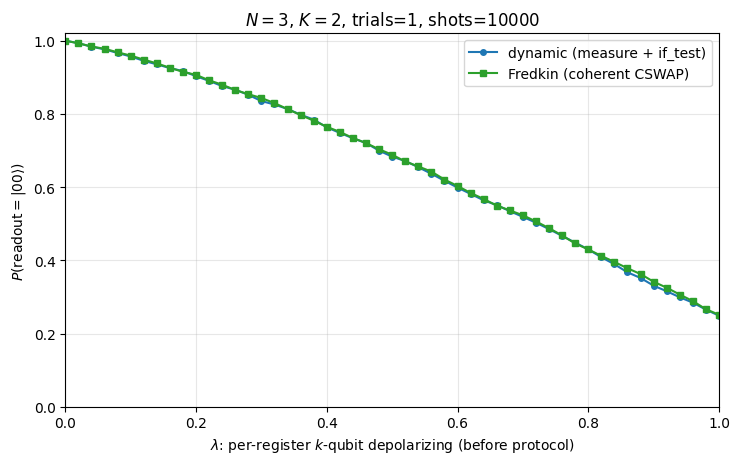

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.75))
ax.plot(lambdas, f_dynamic, "o-", color="C0", markersize=4, linewidth=1.5, label="dynamic (measure + if_test)")
ax.plot(lambdas, f_fredkin, "s-", color="C2", markersize=4, linewidth=1.5, label="Fredkin (coherent CSWAP)")
ax.set_xlabel(r"$\lambda$: per-register $k$-qubit depolarizing (before protocol)")
ax.set_ylabel(r"$P(\mathrm{readout} = |00\rangle)$")
ax.set_title(rf"$N={N_REGS}$, $K={K}$, trials={N_TRIALS}, shots={SHOTS_PER_LAMBDA}")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()

out_dir = Path.cwd()
out_fp = out_dir / "swapnet_n3_k2_compare_fidelity_nb.png"
fig.savefig(out_fp, dpi=150)
print("Saved", out_fp.resolve())
plt.show()


## MPL circuit figures (PNG only, expanded)

Saves alongside the notebook working directory if you run the cells below.

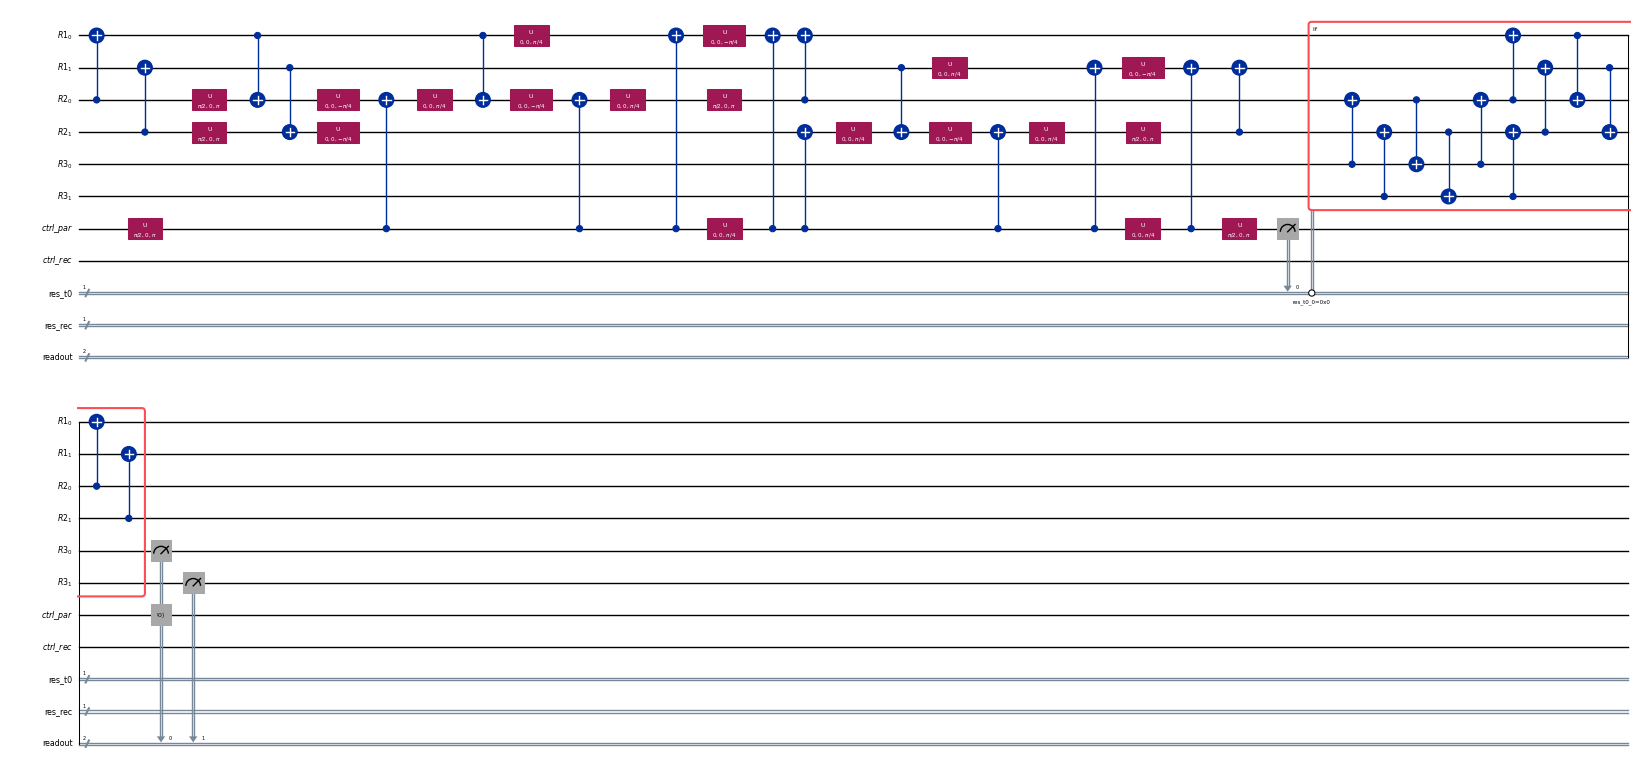

Saved C:\Users\CaioV\OneDrive - The University of Chicago\qc-simulations\OQPA\sandbox\cswaps\swapnet_n3_k2_circuit_dynamic_nb.png


In [ ]:
fig_dyn = circuit_mpl_figure(
    build_dynamic_circuit(CIRCUIT_LAMBDA, N_TRIALS),
    expand_gates=EXPAND_GATES,
    fold=CIRCUIT_FOLD,
    scale=CIRCUIT_SCALE,
)
display(fig_dyn)
p = Path.cwd() / "swapnet_n3_k2_circuit_dynamic_nb.png"
fig_dyn.savefig(p, dpi=150, bbox_inches="tight")
print("Saved", p.resolve())


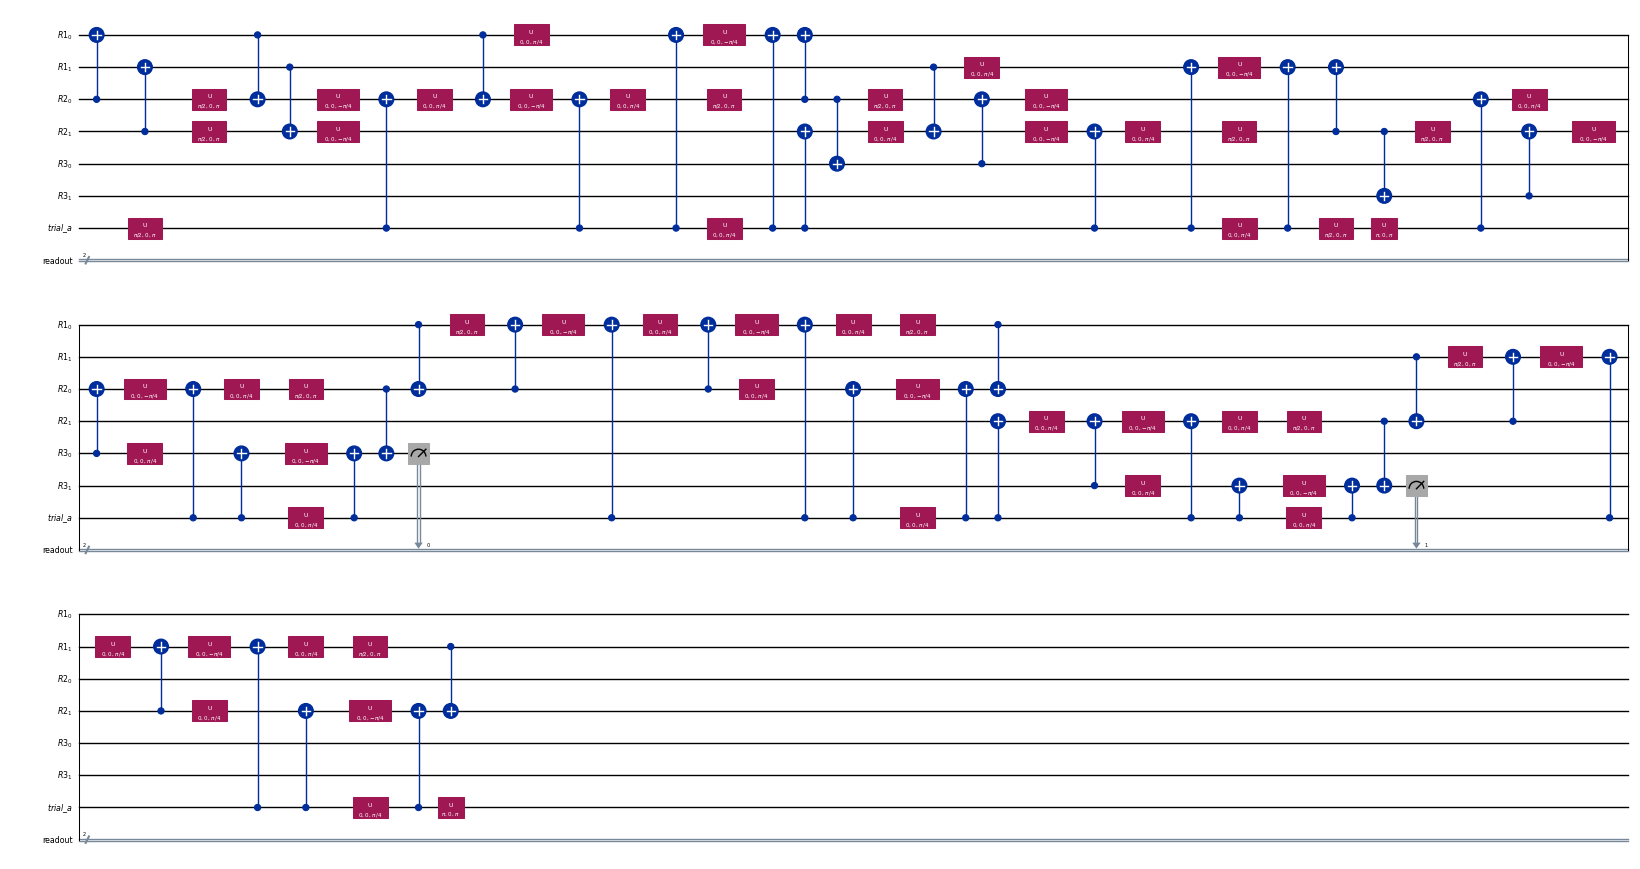

Saved C:\Users\CaioV\OneDrive - The University of Chicago\qc-simulations\OQPA\sandbox\cswaps\swapnet_n3_k2_circuit_fredkin_nb.png


In [ ]:
fig_fre = circuit_mpl_figure(
    build_coherent_circuit(CIRCUIT_LAMBDA, N_TRIALS),
    expand_gates=EXPAND_GATES,
    fold=CIRCUIT_FOLD,
    scale=CIRCUIT_SCALE,
)
display(fig_fre)
p = Path.cwd() / "swapnet_n3_k2_circuit_fredkin_nb.png"
fig_fre.savefig(p, dpi=150, bbox_inches="tight")
print("Saved", p.resolve())


## CLI mirror

The script `swapnet_n3_compare.py` in the same folder is a **batch CLI** for the same algorithms (`--method dynamic|fredkin|both`); keep the notebook and script in sync when you change protocol code.